In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


In [2]:
X, y, *_ = make_blobs(n_samples=200, centers=2, n_features=2,
                      cluster_std=2.5, random_state=123)

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [4]:
def compute_cost(X, y, w, b):
    y_hat = sigmoid(X @ w + b)
    m = len(X)
    cost = 0
    for i in range(m):
        cost += y[i] * np.log(y_hat[i]) + (1-y[i]) * np.log(1-y_hat[i])

    cost = cost / -m
    return cost 

In [5]:
def compute_gradient(X, y, w, b):
    m = len(X)
    f_wb = sigmoid(X @ w + b)
    dj_dw = (X.T @ (f_wb - y)) / m
    dj_db = np.sum(f_wb - y) / m
    return dj_dw, dj_db

In [6]:
def compute_gradient_descent(X, y):
    w = np.zeros_like(X[0], dtype=np.float64)
    b = 0
    alpha = .01
    n_iter = 10000
    
    for _ in range(n_iter):    
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
    return w, b
    

In [7]:
def create_binary_pred(w, b):
    def _pred(x):
        return 1 if sigmoid(np.dot(w, x) + b) >= 0.5 else 0
    return _pred

\begin{aligned}
    f_{\vec{w},b}(\vec{x}) &\geq 0.5 \\
    g(z) &\geq 0.5 \\
    z &\geq 0
\end{aligned}

$$w_1x_1+w_2x_2+b=0$$
$$x_2=\frac{-b-w_1x_1}{w_2}$$

In [8]:
w, b = compute_gradient_descent(X, y)
pred = create_binary_pred(w, b)
x_test = [4, 5.1]
p = pred(x_test)
print(f"Weights:", w, "Bias:", b)
print(f"Predict for {x_test}: {p:.3f}")

Weights: [-1.77304912  0.9812838 ] Bias: 0.11653667265545938
Predict for [4, 5.1]: 0.000


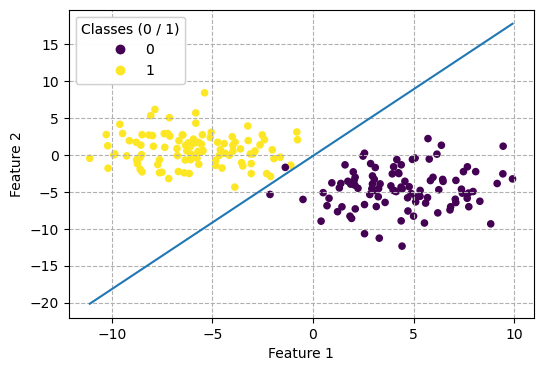

In [9]:
x1 = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 10)
x2 = (-b - w[0] * x1) / w[1]

fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(X[:, 0], X[:, 1], s=20, c=y)
plot, = ax.plot(x1, x2, label='Decision Boundary')

legend1 = ax.legend(title="Classes (0 / 1)", *scatter.legend_elements())

ax.add_artist(legend1)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(linestyle='--')
plt.show()